[2026-07-22 13:40:02] [info     ] 计算 [vB] RV-Weighted DSR 因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59


[2026-07-22 13:41:44] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-22 13:41:44] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-22 13:41:48] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-22 13:41:48] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-22 13:41:49] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-22 13:41:49] [info     ] ========== 数据检查 ==========
[2026-07-22 13:41:49] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset

时段,IC
2024-01-15~2024-02-08,0.0087
2024-09-24~2024-10-08,0.0257

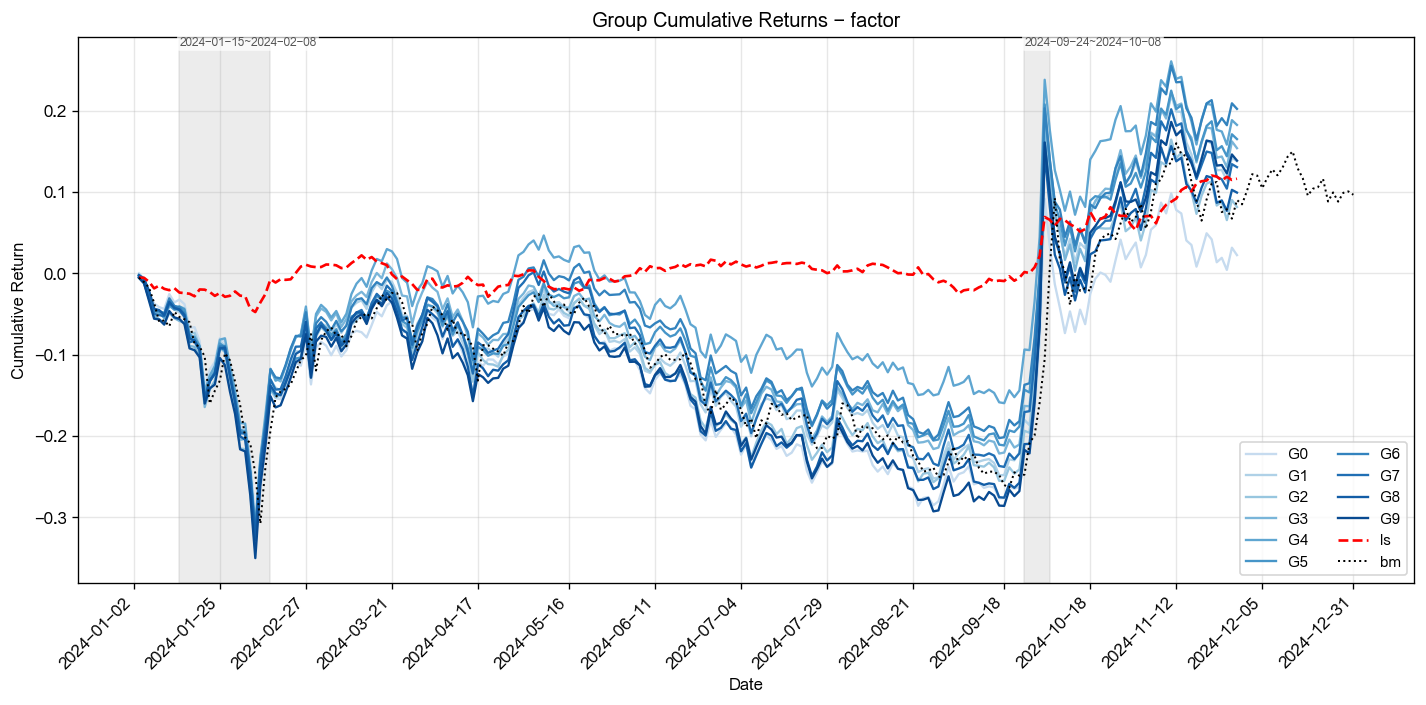
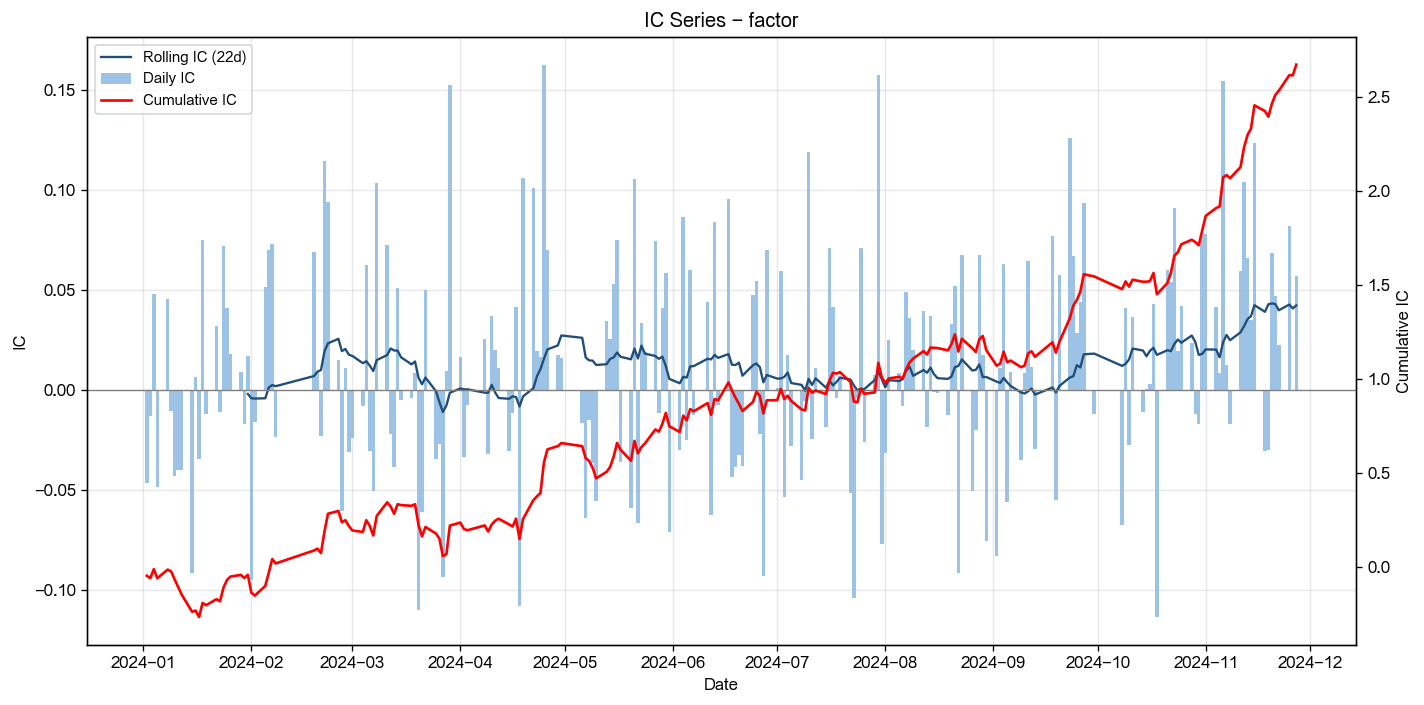
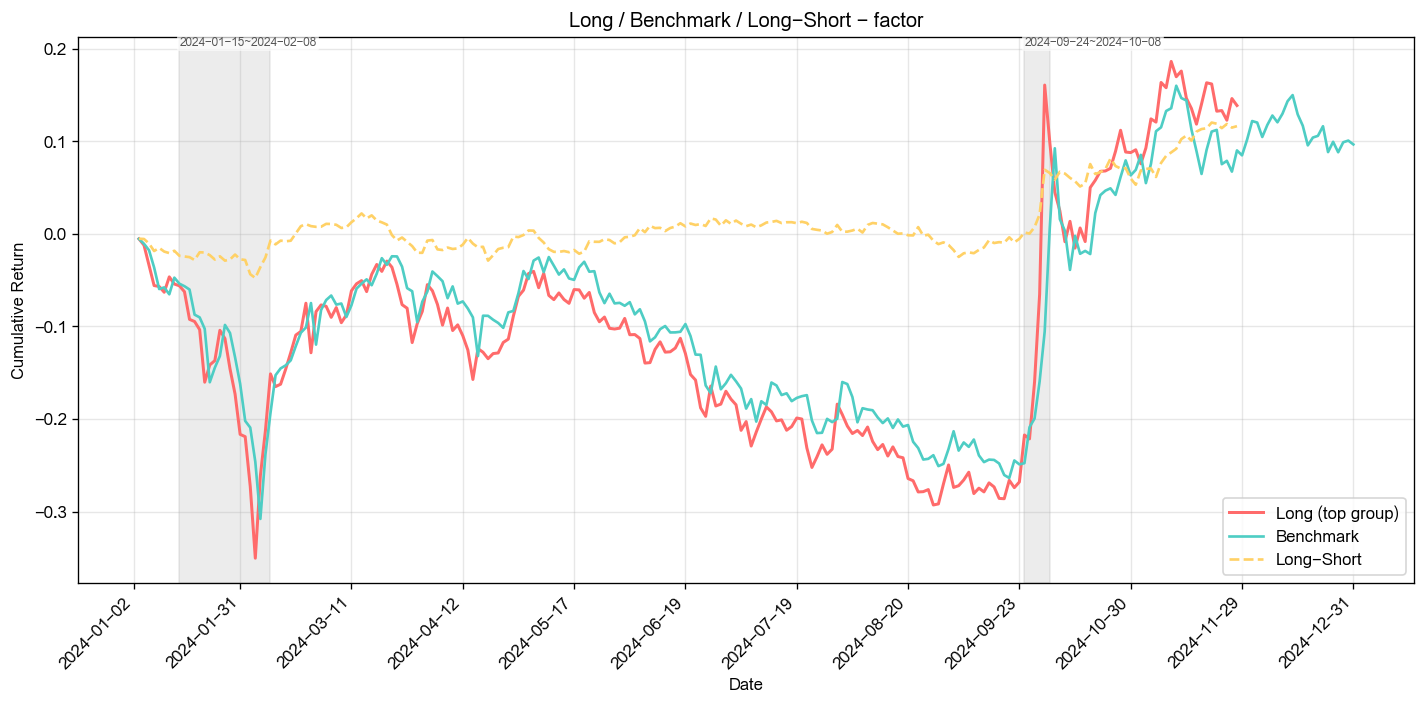
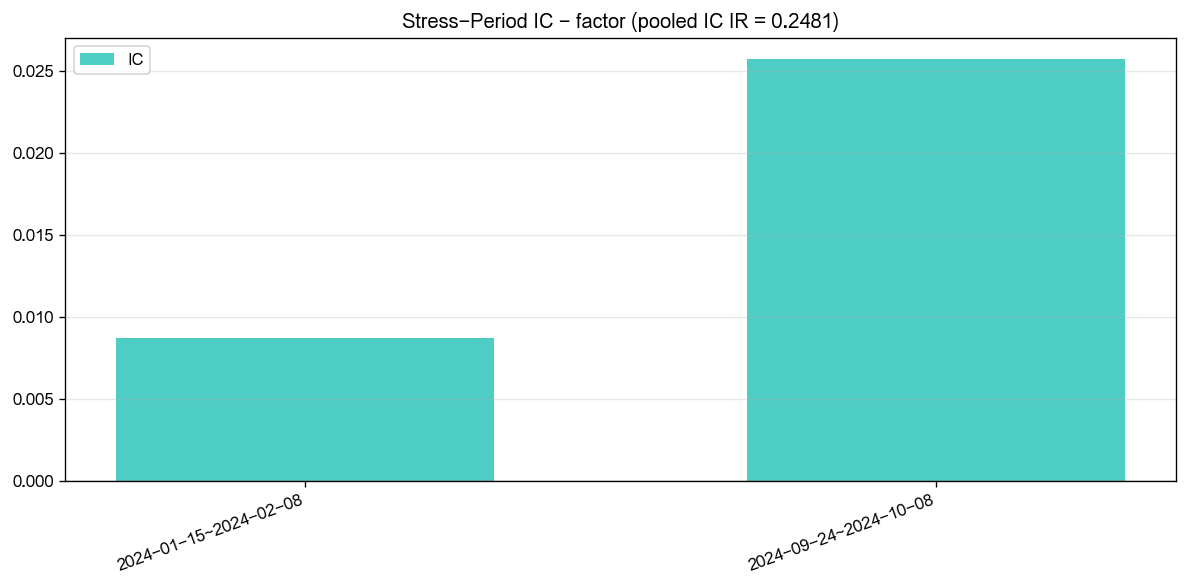
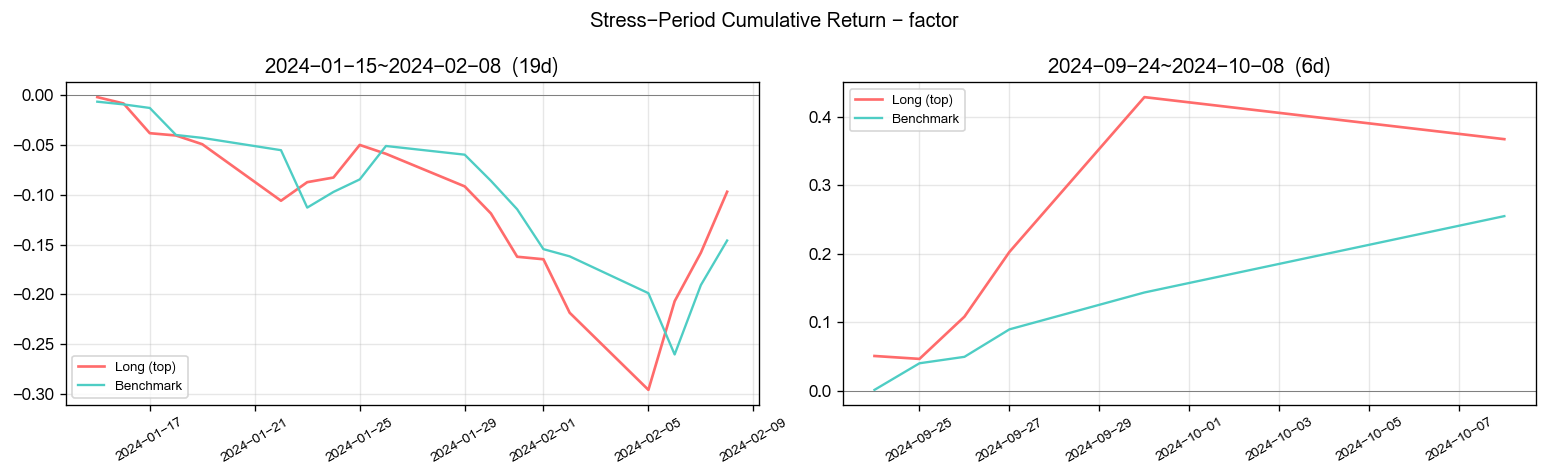

[2026-07-22 13:43:14] [info     ] ========== 因子池回归 ==========
[2026-07-22 13:43:14] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-22 13:43:15] [info     ] 获取收益率数据, 耗时: 1.9113 秒
[2026-07-22 13:43:17] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.7972 秒
[2026-07-22 13:43:17] [info     ] 统计 回归结果, 耗时: 0.021 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.8920,0.0457,0.0241,1.0000
2,amount,1.7587,0.0189,0.0108,1.0000
3,factor,1.5971,0.0050,0.0031,0.9000
4,netflow_amount_rate_main,1.5332,0.0099,0.0065,1.0000
5,gross_profit_rate_ttm,1.5187,0.0069,0.0046,1.0000
6,netflow_amount_main,1.5111,0.0252,0.0167,1.0000
7,pb,1.4580,0.0098,0.0067,1.0000
8,net_profit_rate_ttm,1.4490,0.0042,0.0029,0.8000
9,bias_20,1.4348,0.0293,0.0204,0.9000
10,cci_14,1.3696,0.0337,0.0246,1.0000

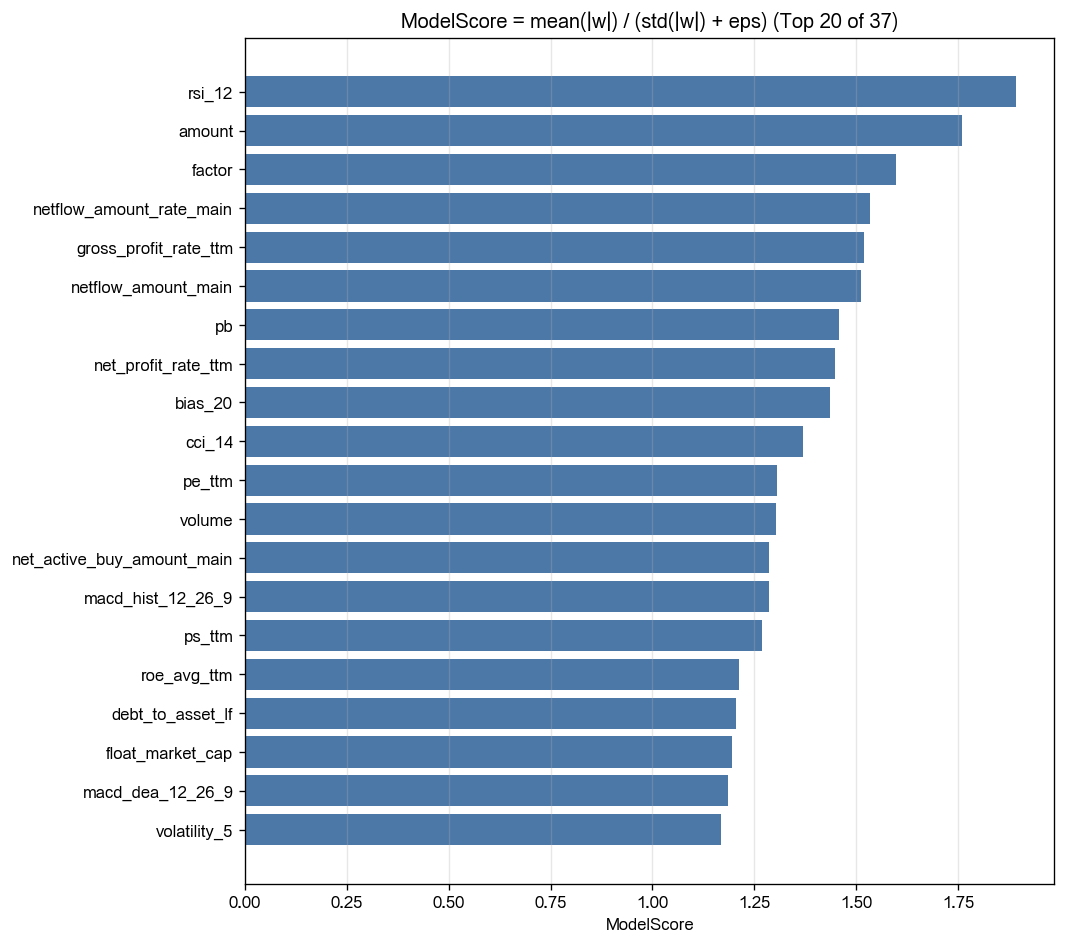
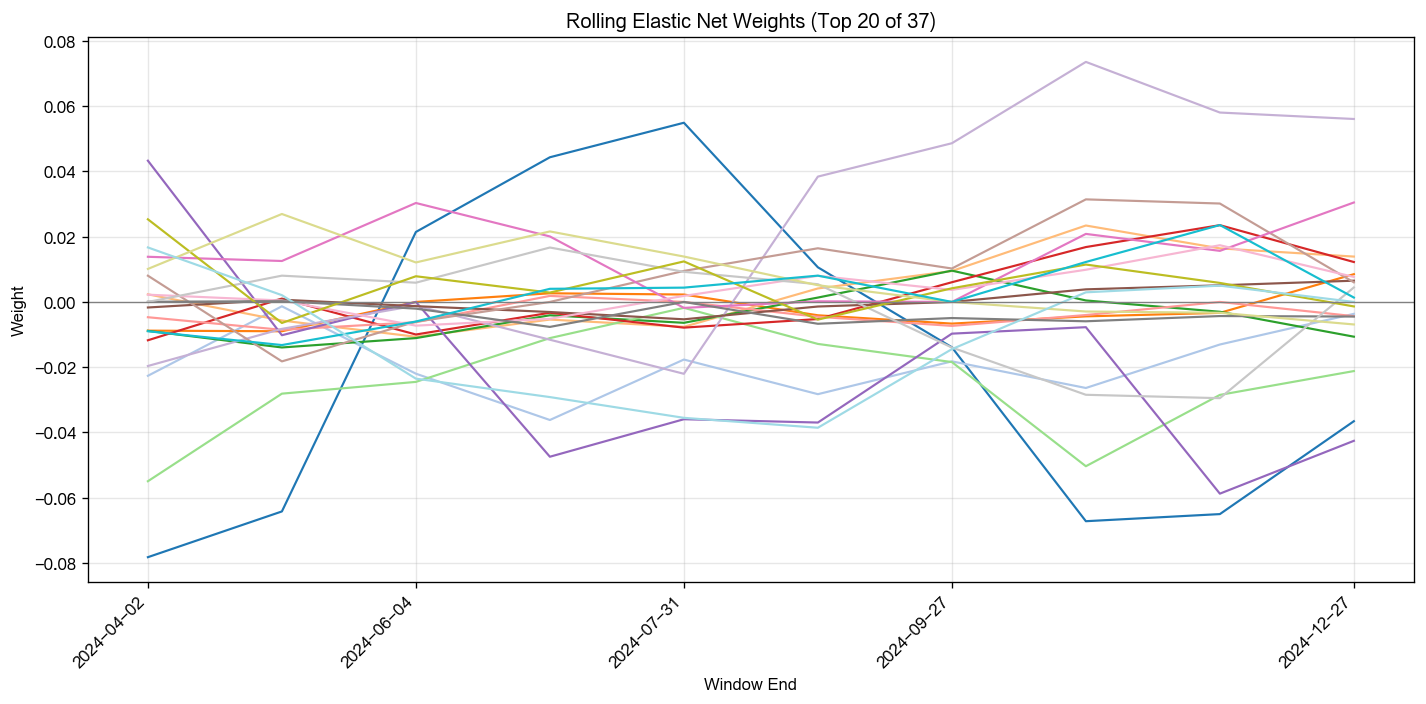
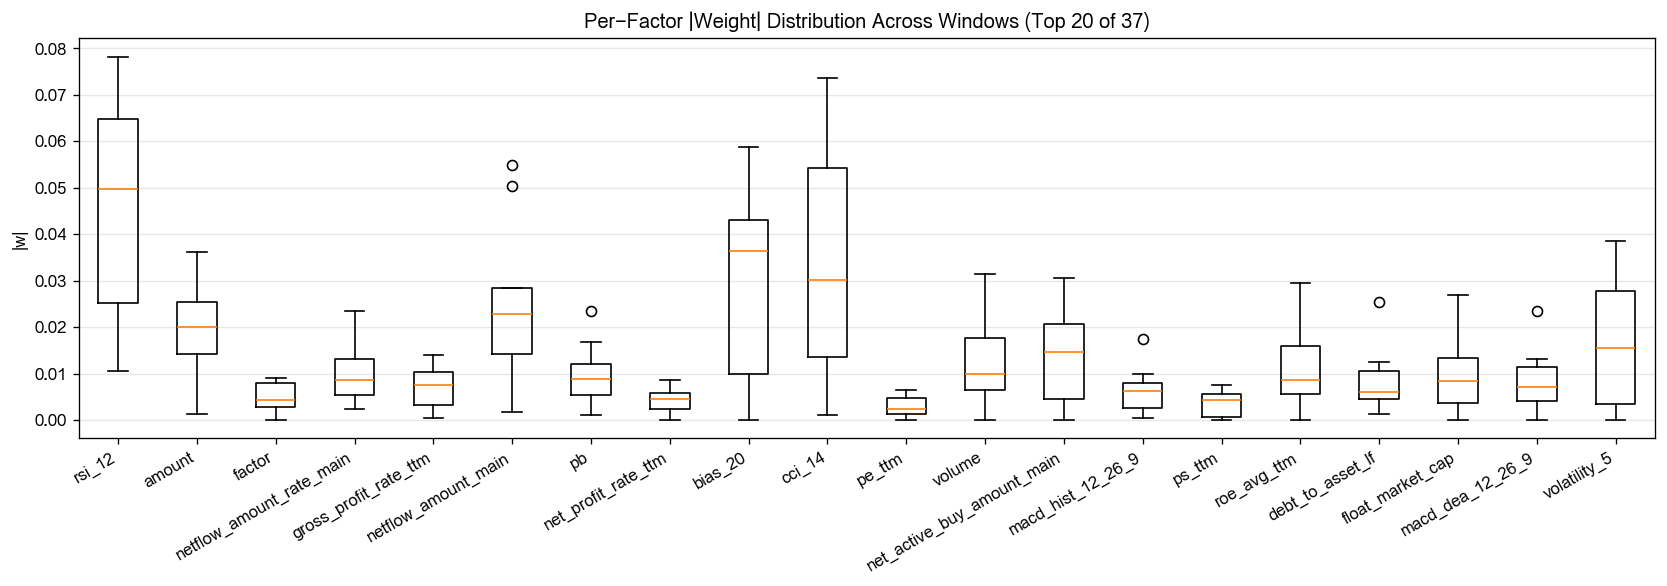
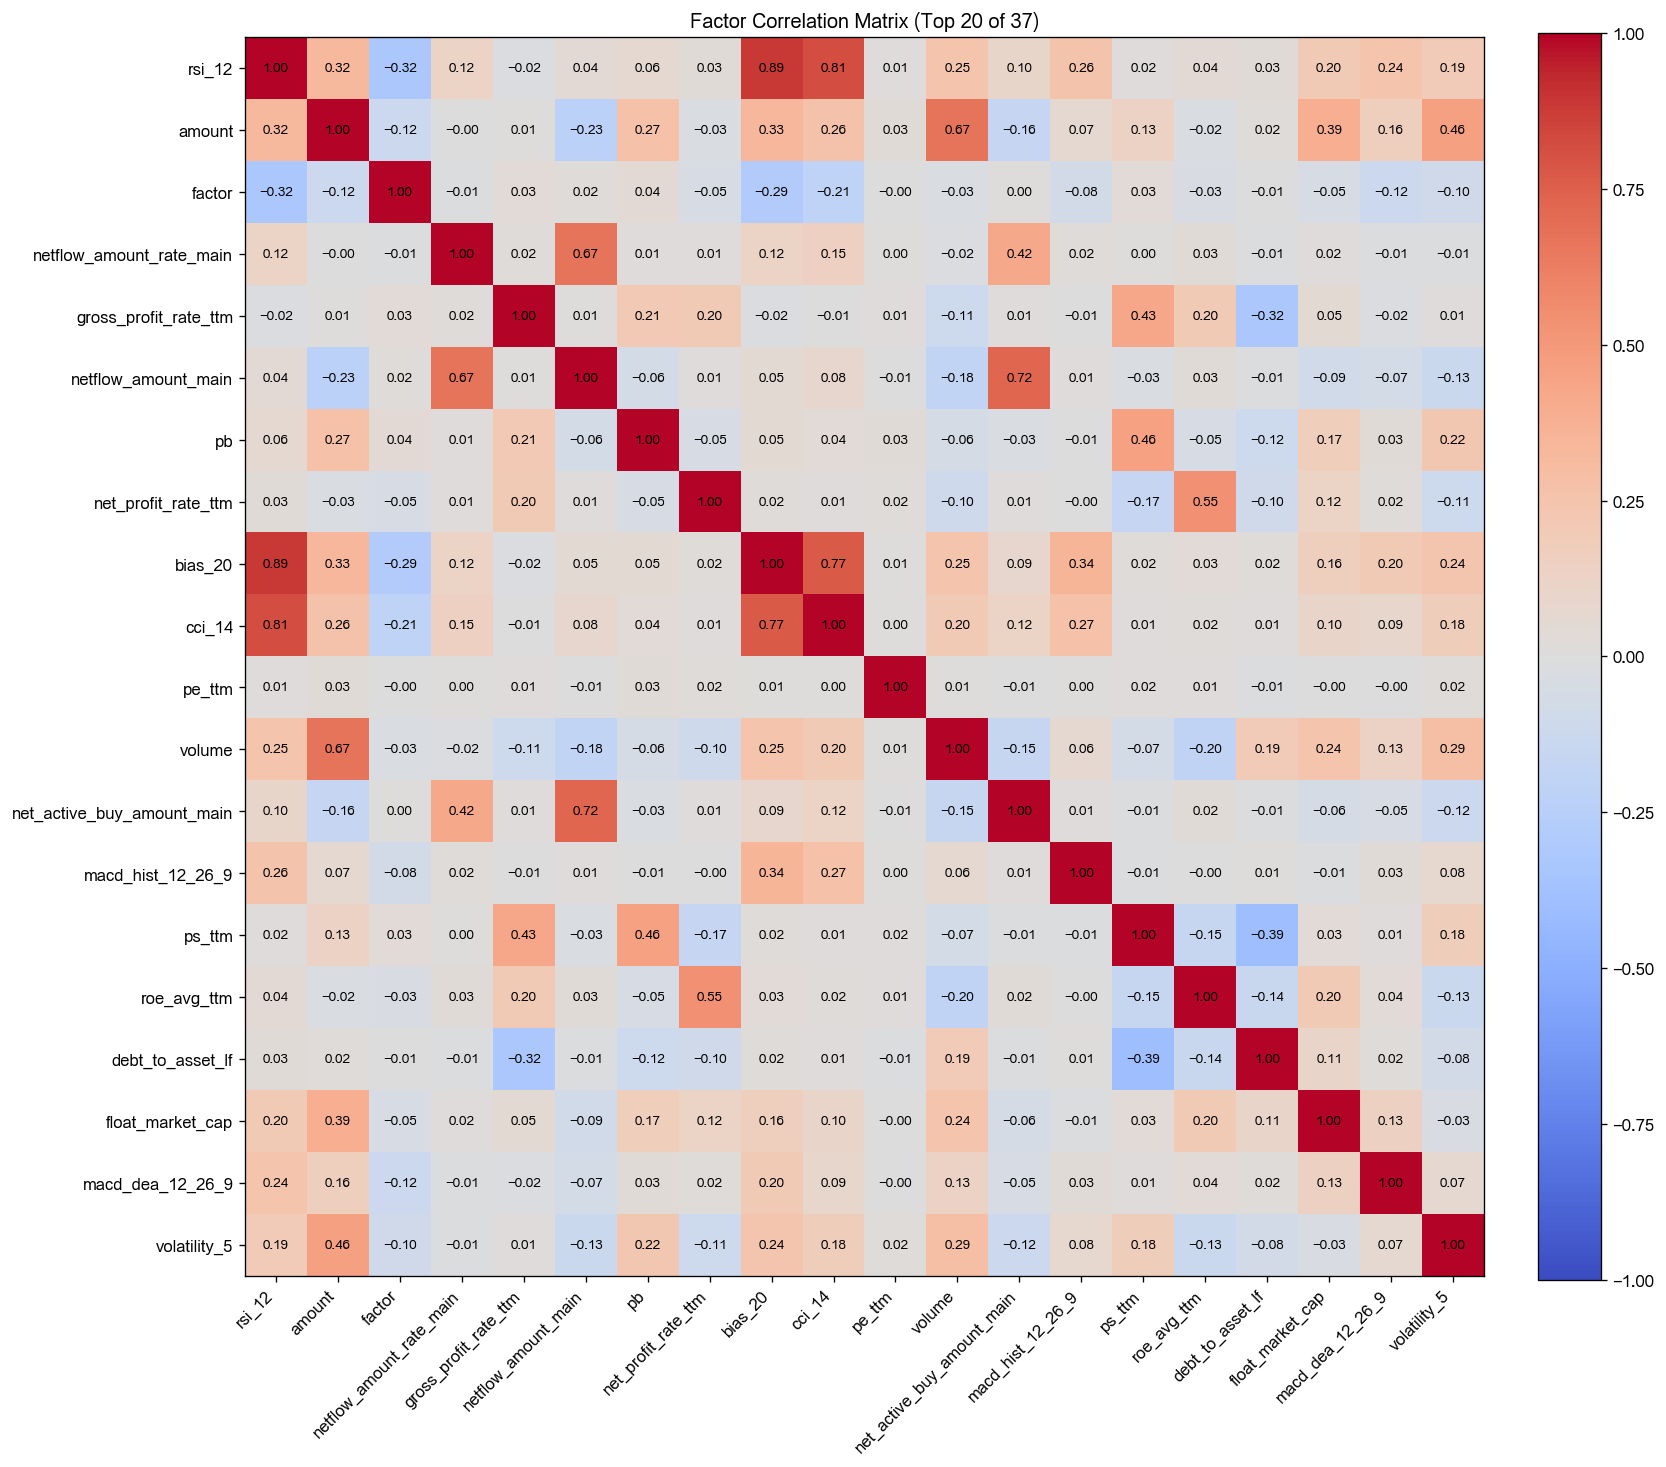

[2026-07-22 13:43:21] [warning  ] 返回的Outputs实例(size=35214300) 大于 64K, 将不会被缓存
[2026-07-22 13:43:21] [info     ] bigalpha_eval.v4 运行完成 [93.442s].


In [2]:
def main(datasources, start_date, end_date):
    """计算 RV 加权 DSR 因子"""
    import dai
    import pandas as pd
    import numpy as np

    bar1m_table = datasources["bar1m"]

    lookback_start_dt = pd.to_datetime(start_date) - pd.Timedelta(days=60)
    lookback_start = lookback_start_dt.strftime("%Y-%m-%d")
    query_end_dt = pd.to_datetime(end_date) + pd.Timedelta(days=1)
    query_end = query_end_dt.strftime("%Y-%m-%d")

    # CC: DAI SQL — 日频 RV⁺ 和 RV⁻（与原版相同）
    sql = f"""
    WITH cte_ret AS (
        SELECT date, instrument,
               (close - LAG(close) OVER w) / NULLIF(LAG(close) OVER w, 0) AS ret
        FROM {bar1m_table}
        WINDOW w AS (PARTITION BY instrument, date::DATE ORDER BY date)
    )
    SELECT date::DATE AS date, instrument,
           SUM(CASE WHEN ret > 0 THEN ret * ret ELSE 0 END) AS rv_up,
           SUM(CASE WHEN ret < 0 THEN ret * ret ELSE 0 END) AS rv_down,
           COUNT(*) AS n_minutes
    FROM cte_ret
    WHERE ret IS NOT NULL
    GROUP BY date::DATE, instrument
    """

    daily_df = dai.query(sql, filters={'date': [lookback_start, query_end]}).df()
    daily_df['date'] = pd.to_datetime(daily_df['date'])

    # CC: 过滤日内分钟数过少的交易日
    daily_df = daily_df[daily_df['n_minutes'] >= 120]

    # CC: DSR = RV⁻ / (RV⁺ + RV⁻)
    total_rv = daily_df['rv_up'] + daily_df['rv_down']
    daily_df['dsr'] = daily_df['rv_down'] / total_rv.replace(0, np.nan)
    daily_df['dsr'] = daily_df['dsr'].fillna(0.5)

    # 🆕 改动：计算日权重 = total_RV 的每日横截面 percentile rank
    #   🔑 用截面排名而非绝对 RV 值：
    #      - 每天权重在 [0, 1] 内均匀分布，不受市场整体 RV 水平影响
    #      - crash 日不会因为市场 RV 飙升而获得超额权重
    #      - 同一日内部：高 RV 股票权重高 → DSR 估计更可靠 → 理应获得更高权重
    #      - 本质是"相对波动性"而非"绝对波动性"
    daily_df['total_rv'] = total_rv
    daily_df['weight'] = daily_df.groupby('date')['total_rv'].rank(pct=True)

    # 🆕 改动：20 日加权滚动均值（仅用 mean，去掉 std）
    daily_df = daily_df.sort_values(['instrument', 'date'])

    def weighted_rolling_mean(group):
        """在 group 内做 20 日加权滚动均值（min_periods=10）"""
        dsr_vals = group['dsr'].values
        w_vals = group['weight'].values
        n = len(dsr_vals)
        result = np.full(n, np.nan)
        for i in range(n):
            start = max(0, i - 20 + 1)
            end = i + 1
            # min_periods=10：不足 10 个有效日则不计算
            if end - start < 10:
                continue
            w = w_vals[start:end]
            if w.sum() > 1e-10:
                result[i] = np.average(dsr_vals[start:end], weights=w)
        # 🔑 必须返回 Series（带 index），否则 apply 无法对齐
        return pd.Series(result, index=group.index)

    # CC: groupby().apply()，返回的 Series 自动按 index 对齐回 daily_df
    daily_df['factor'] = daily_df.groupby('instrument', group_keys=False).apply(
        weighted_rolling_mean
    )

    # CC: 截取评测区间 + 股票池对齐
    mask = (daily_df['date'] >= start_date) & (daily_df['date'] <= end_date)
    result = daily_df[mask][['date', 'instrument', 'factor']].copy()

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])

    result = pd.merge(stk_pool, result, how='left', on=['date', 'instrument'])
    result = result.replace([np.inf, -np.inf], np.nan)

    # CC: 不取相反数——DSR 预期方向为正
    result = result[['date', 'instrument', 'factor']]
    return result


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算 [vB] RV-Weighted DSR 因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )

